In [1]:
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", message="Detected IPython.*")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.discriminant_analysis import StandardScaler
import utils as ut
import model_wrappers as mw
import networkx as nx
import math
from hyperparameter import model_configs

import shap
import simulation_production as sim



Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Create the simulation

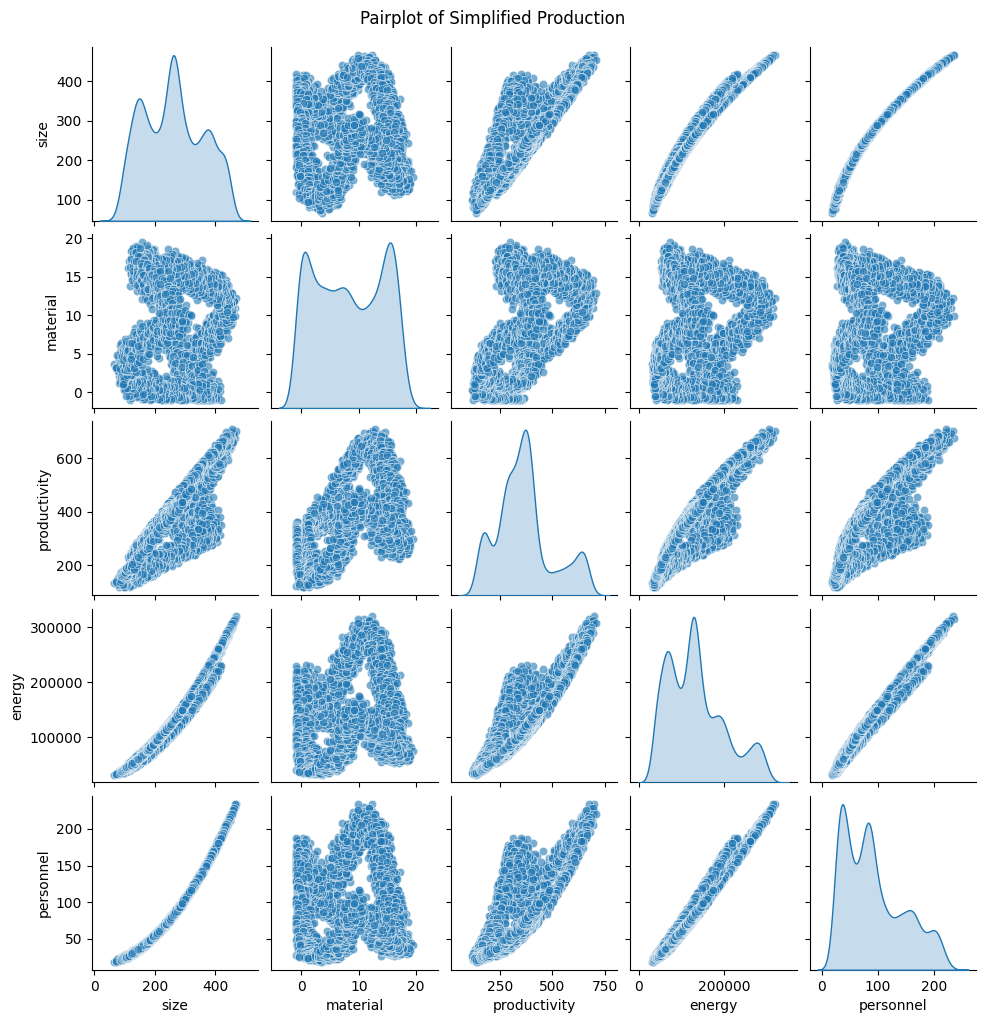

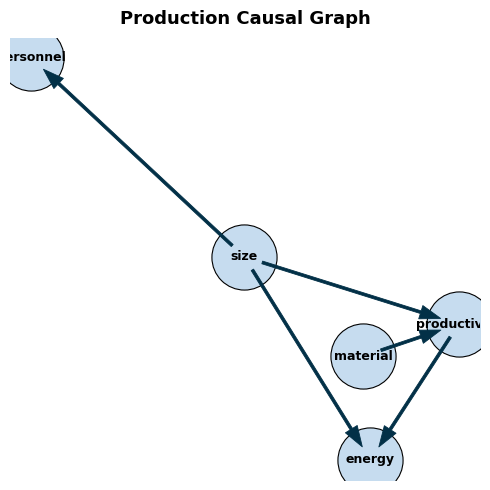

In [2]:


# Generate data and plot
synthetic_df = sim.simulation(n_samples=8000)

# Create pairplot
sns.pairplot(synthetic_df, diag_kind='kde', plot_kws={'alpha': 0.6}, height=2)
plt.suptitle("Pairplot of Simplified Production", y=1.02)
plt.show()

# Define variables and causal structure
var_names = ["personnel", "energy", "material", "size"]

causal_links = {
    "productivity": ["size", "material"],          
    "energy": ["productivity", "size"],
    "personnel": ["size"]
}

# Create and plot causal graph
G = ut.create_causal_graph(var_names, causal_links)
ut.plot_causal_graph(G, title="Production Causal Graph")

# Train and evaluate the models

In [3]:
model_configs

{'RandomForest': {'model_class': sklearn.ensemble._forest.RandomForestRegressor,
  'params': {'random_state': 42},
  'param_grid': {'n_estimators': [100, 200, 1000],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 15]}},
 'LinearRegression': {'model_class': sklearn.linear_model._base.LinearRegression},
 'MLP': {'model_class': model_wrappers.MLPRegressorWrapper,
  'param_grid': {'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
   'alpha': [0.001, 0.01],
   'learning_rate': ['constant', 'adaptive']}},
 'XGBoost': {'model_class': model_wrappers.XGBRegressorWrapper,
  'params': {'random_state': 42},
  'param_grid': {'max_depth': [3, 5, 10],
   'learning_rate': [0.01, 0.1, 0.5],
   'n_estimators': [100, 200, 1000]}},
 'GAM': {'model_class': model_wrappers.GAMRegressorWrapper, 'params': {}},
 'SymbolicRegression': {'model_class': model_wrappers.SymbolicRegressor}}

In [4]:

# Define storage for equations
symbolic_equations = {
    "causal": {},      
    "traditional": {}  
}
trained_models = {}  
results = []

# Define training, testing data and target
train_size = 8000
total_samples = int(train_size * 2)

data = sim.simulation(n_samples=total_samples, seed=42)
train_df, test_df = data[:train_size], data[train_size:]
target = "energy"
X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Define the what-if analysis and generate the ground truth
intervention = 300
ground_truth_intervention = sim.simulation(n_samples=total_samples, seed=42, intervention=intervention)[:train_size]

# Train and evaluate every model
for name, cfg in model_configs.items():
    print(name)
    ModelClass = cfg["model_class"]
    params = cfg.get("params", {})
    param_grid = cfg.get("param_grid", None)

    # --- Causal version ---
    causal_models = ut.train_causal_models(train_df, G, ModelClass, model_params=params, param_grid=param_grid)
    causal_preds = ut.predict_causal(test_df, G, causal_models, what_if=False)
    rmse_c, wape_c, mae_c = ut.evaluate_metrics(test_df[target], causal_preds[target])
    results.append(["Causal", name, rmse_c, wape_c, mae_c, "Test"])
    
    # Extract equations for causal models (for SymbolicRegression only)
    # In the loop, after getting equation:
    if name == "SymbolicRegression":
        symbolic_equations["causal"][name] = {}
        for node, model in causal_models.items():
            try:
                equation = str(model.model.get_best()['equation'])
                equation = ut.round_numbers_in_string(equation)  # Round numbers
                symbolic_equations["causal"][name][node] = equation
                print(f"[Causal {name}] Node '{node}': {equation}")
            except:
                symbolic_equations["causal"][name][node] = "No equation available"

    # --- Traditional ML version with hyperparameter tuning ---
    if param_grid:
        base_model = ModelClass(**params)
        grid_search = GridSearchCV(base_model, param_grid=param_grid, cv=4, n_jobs=-1, scoring='neg_mean_absolute_error')
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
        print(f"[GridSearchCV] Best params for Traditional '{name}': {grid_search.best_params_}")
    else:
        model = ModelClass(**params)
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse_t, wape_t, mae_t = ut.evaluate_metrics(y_test, y_pred)
    results.append(["Traditional", name, rmse_t, wape_t, mae_t, "Test"])
    
    # Extract equation for traditional model (for SymbolicRegression only)
    # Similarly for traditional:
    if name == "SymbolicRegression":
        try:
            equation = str(model.model.get_best()['equation'])
            equation = ut.round_numbers_in_string(equation)  # Round numbers
            symbolic_equations["traditional"][name] = equation
            print(f"[Traditional {name}] Target equation: {equation}")
        except:
            symbolic_equations["traditional"][name] = "No equation available"

    # --- Intervention scenario ---
    data_base = X_train.copy()
    data_base["size"] = intervention
    
    causal_preds_intervention = ut.predict_causal(data_base, G, causal_models, what_if=True)
    rmse_c_int, wape_c_int, mae_c_int = ut.evaluate_metrics(
        ground_truth_intervention[target], causal_preds_intervention[target]
    )
    results.append(["Causal", name, rmse_c_int, wape_c_int, mae_c_int, "Intervention"])

    y_pred_int = model.predict(data_base)
    rmse_t_int, wape_t_int, mae_t_int = ut.evaluate_metrics(
        ground_truth_intervention[target], y_pred_int
    )
    results.append(["Traditional", name, rmse_t_int, wape_t_int, mae_t_int, "Intervention"])

    # Store the trained models
    trained_models[name] = {"causal": causal_models, "traditional": model}


RandomForest
[GridSearchCV] Best params for Traditional 'RandomForest': {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 1000}
LinearRegression
MLP
[GridSearchCV] Best params for Traditional 'MLP': {'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}
XGBoost
[GridSearchCV] Best params for Traditional 'XGBoost': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1000}
GAM
SymbolicRegression
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython

In [5]:
# Organize the resutls a

results_df = pd.DataFrame(results, columns=["Model_Type", "Algorithm", "RMSE", "WAPE", "MAE", "Task"])
results_df = results_df[["Model_Type", "Algorithm", "MAE", "RMSE", "WAPE", "Task"]]
results_df = results_df.round(4)


if symbolic_equations["causal"]:
    print("\n--- CAUSAL MODELS ---")
    for model_name, node_equations in symbolic_equations["causal"].items():
        print(f"\n{model_name}:")
        for node, equation in node_equations.items():
            print(f"  {node}: {equation}")

if symbolic_equations["traditional"]:
    print("\n--- TRADITIONAL MODELS ---")
    for model_name, equation in symbolic_equations["traditional"].items():
        print(f"{model_name}: {equation}")

print("\n" + "="*80)
display(results_df)
print("\n" + "="*80)
print(trained_models)


--- CAUSAL MODELS ---

SymbolicRegression:
  personnel: (size * (size * 0.0010)) + 14.9813
  energy: (productivity * 130.0056) - (-9998.7280 - (size * size))
  productivity: (((log1p(material) + 1.7779) / 3.1755) * size) + 63.5110

--- TRADITIONAL MODELS ---
SymbolicRegression: ((personnel * 993.9957) + (productivity * 132.6140)) - 5526.7470



,Model_Type,Algorithm,MAE,RMSE,WAPE,Task
0,Causal,RandomForest,8941.6591,12121.5976,7.6310,Test
1,Traditional,RandomForest,9150.5342,12308.9708,7.8092,Test
2,Causal,RandomForest,1083.3766,1487.6498,0.6699,Intervention
3,Traditional,RandomForest,14013.0083,15039.8835,8.6649,Intervention
4,Causal,LinearRegression,11134.4783,14122.7942,9.5024,Test
5,Traditional,LinearRegression,871.7708,1091.9058,0.7440,Test
6,Causal,LinearRegression,10011.9696,10259.0133,6.1909,Intervention
7,Traditional,LinearRegression,67071.1320,75544.8099,41.4733,Intervention
8,Causal,MLP,14211.2358,18518.7456,12.1281,Test
9,Traditional,MLP,1621.7075,2335.5484,1.3840,Test



{'RandomForest': {'causal': {'personnel': RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42), 'energy': RandomForestRegressor(max_depth=20, n_estimators=1000, random_state=42), 'productivity': RandomForestRegressor(n_estimators=1000, random_state=42)}, 'traditional': RandomForestRegressor(max_depth=20, n_estimators=1000, random_state=42)}, 'LinearRegression': {'causal': {'personnel': LinearRegression(), 'energy': LinearRegression(), 'productivity': LinearRegression()}, 'traditional': LinearRegression()}, 'MLP': {'causal': {'personnel': <model_wrappers.MLPRegressorWrapper object at 0x7f2997f1c190>, 'energy': <model_wrappers.MLPRegressorWrapper object at 0x7f2997f1ff50>, 'productivity': <model_wrappers.MLPRegressorWrapper object at 0x7f2998325890>}, 'traditional': <model_wrappers.MLPRegressorWrapper object at 0x7f2995573290>}, 'XGBoost': {'causal': {'personnel': <model_wrappers.XGBRegressorWrapper object at 0x7f2995566b90>, 'energy': <model_wrappers.XGBRegressorWrapp

# Results

In [6]:
# Divide the resutls between test set and what-if analysis
df = results_df.copy()

df = df.round(4)

df['Model_Type'] = df['Model_Type'].replace({'Causal': 'CML', 'Traditional': 'ML'})
df['Algorithm'] = df['Algorithm'].replace({'RandomForest': 'RForest', 'SymbolicRegression': 'Symbolic',
                                           'XGBRegression': 'XGB', 'LinearRegression': 'Linreg',})

df.columns = ["Type", "Model", "MAE", "RMSE", "WAPE", "Task"]

# Filter for Intervention task and drop Task column
intervention_df = df[df["Task"] == "Intervention"].drop(columns=["Task"]).sort_values(by=["MAE"])

# Filter for Test task and drop Task column
test_df = df[df["Task"] == "Test"].drop(columns=["Task"]).sort_values(by=["MAE"])

# Display the Intervention table with 5 significant digits for numeric columns
print("Intervention Results:")
intervention_df = intervention_df.style.hide(axis='index').format({'MAE': '{:.5g}', 'RMSE': '{:.5g}', 'WAPE': '{:.5g}'})
display(intervention_df)

# Display the Test table with 5 significant digits for numeric columns
print("\nTest Results:")
display(test_df.style.hide(axis='index').format({'MAE': '{:.5g}', 'RMSE': '{:.5g}', 'WAPE': '{:.5g}'}))

Intervention Results:


Type,Model,MAE,RMSE,WAPE
CML,Symbolic,546.37,685.41,0.3378
CML,GAM,647.71,809.39,0.4005
CML,RForest,1083.4,1487.6,0.6699
CML,XGBoost,1094.2,1295.1,0.6766
CML,MLP,2757.5,3547.6,1.7051
CML,Linreg,10012,10259,6.1909
ML,RForest,14013,15040,8.6649
ML,GAM,16550,18830,10.233
ML,XGBoost,20941,23622,12.949
ML,Linreg,67071,75545,41.473



Test Results:


Type,Model,MAE,RMSE,WAPE
CML,Symbolic,161.76,201.73,0.1381
CML,GAM,184.14,238.21,0.1572
ML,GAM,199.41,254.77,0.1702
ML,Linreg,871.77,1091.9,0.744
ML,Symbolic,873.22,1087.2,0.7452
ML,MLP,1621.7,2335.5,1.384
ML,XGBoost,3770.7,5589.1,3.218
CML,XGBoost,4147.5,6187,3.5396
CML,RForest,8941.7,12122,7.631
ML,RForest,9150.5,12309,7.8092


# Shap for the ML XGBoost

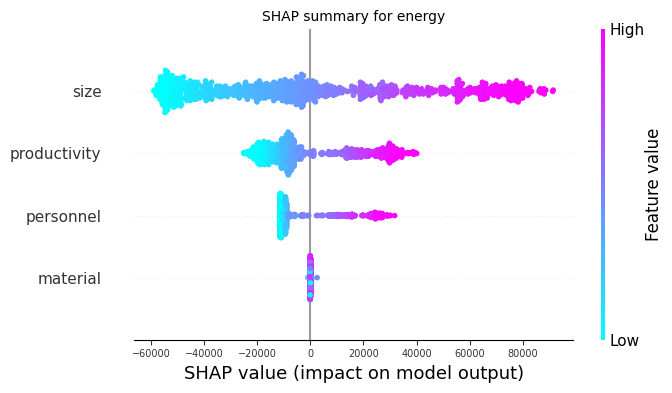

In [7]:
rf_model = trained_models["XGBoost"]["traditional"]

# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(rf_model.model)

# Sample data for SHAP
X_sample = X_train.sample(1000, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Create Explanation object for beeswarm
explanation = shap.Explanation(values=shap_values, data=X_sample.values, feature_names=X_sample.columns)

# Make base fonts a bit smaller
plt.rcParams.update({"font.size": 9})

# Create 1 subplot (since it's one traditional model)
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

# Beeswarm plot
shap.plots.beeswarm(explanation, ax=ax, show=False, plot_size=None, color=plt.get_cmap("cool",))

# Title and smaller x-axis tick labels
ax.set_title('SHAP summary for energy', fontsize=10)
ax.tick_params(axis='x', labelsize=7)   # make x-axis values smaller
ax.tick_params(axis='y', labelsize=11)   # optional: slightly smaller y labels

plt.tight_layout()
# plt.savefig('visuals/traditional_shap_beeswarm.svg', format='svg', bbox_inches='tight')
plt.savefig('visuals/traditional_shap_beeswarm.svg', format='svg', bbox_inches='tight', dpi=1000)
plt.savefig('visuals/traditional_shap_beeswarm.pdf', format='pdf', bbox_inches='tight', dpi=500)
plt.show()


# Partial dependence plot for the ML GAM

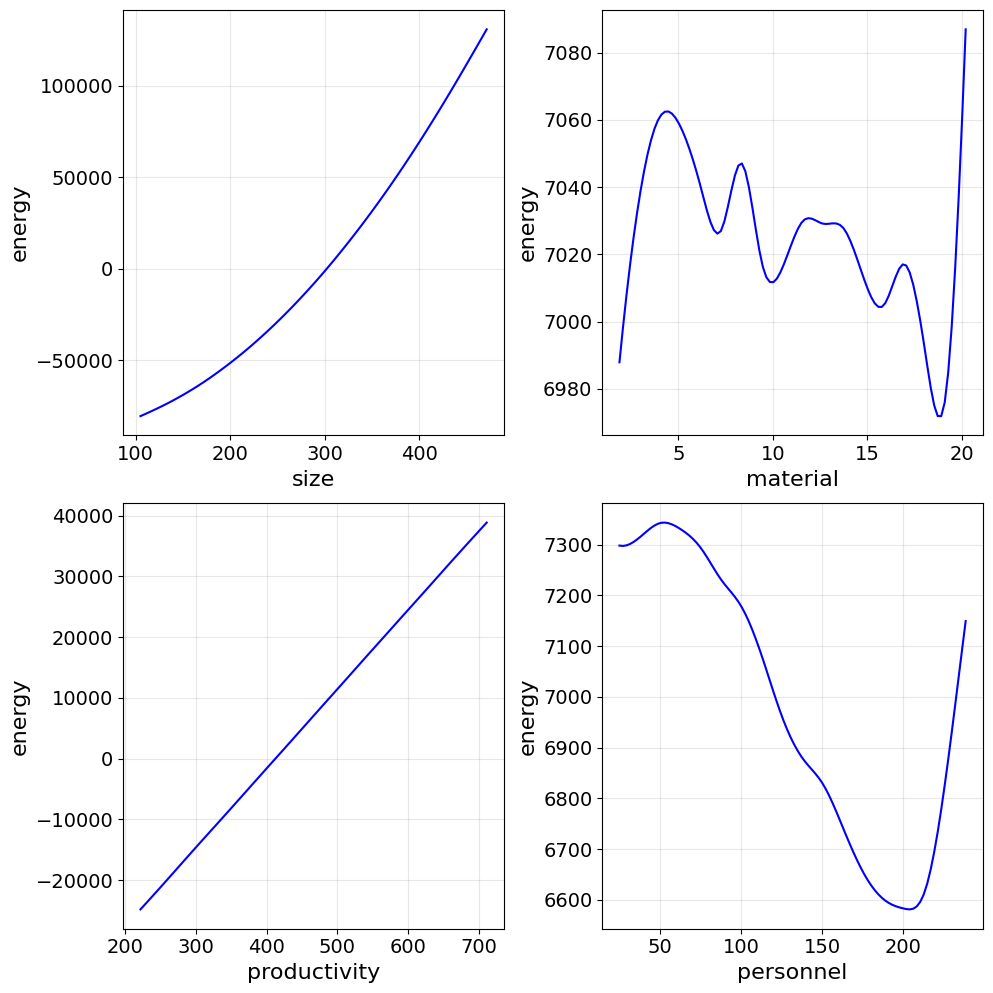

In [8]:

features = list(X_train.columns)
n_features = len(features)

for name, model_dict in trained_models.items():
    if name != "GAM":
        continue  # Only plot for GAM
    
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))  # 2x2 grid
    
    gam_model = model_dict["traditional"].model  # Access the underlying LinearGAM
    
    for i, feature in enumerate(features):
        try:
            # Generate grid for this term
            XX = gam_model.generate_X_grid(term=i)
            pdep = gam_model.partial_dependence(term=i, X=XX)
            
            ax = axes.flat[i]  # Use flat indexing for 2x2 grid
            ax.plot(XX[:, i], pdep, color='blue')
            ax.set_xlabel(feature, fontsize=16)
            ax.set_ylabel('energy', fontsize=16)
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.grid(True, alpha=0.3)
            
            # Format x-axis in scientific notation for 'energy'
            if feature == "energy":
                ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        except Exception as e:
            ax = axes.flat[i]
            ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center', transform=ax.transAxes, fontsize=12)
    
    plt.tight_layout()
    plt.savefig('visuals/partial_dependence_plots_traditional.pdf', format='pdf', bbox_inches='tight', dpi=500)
    plt.show()

# Shap for the causal XGBoost

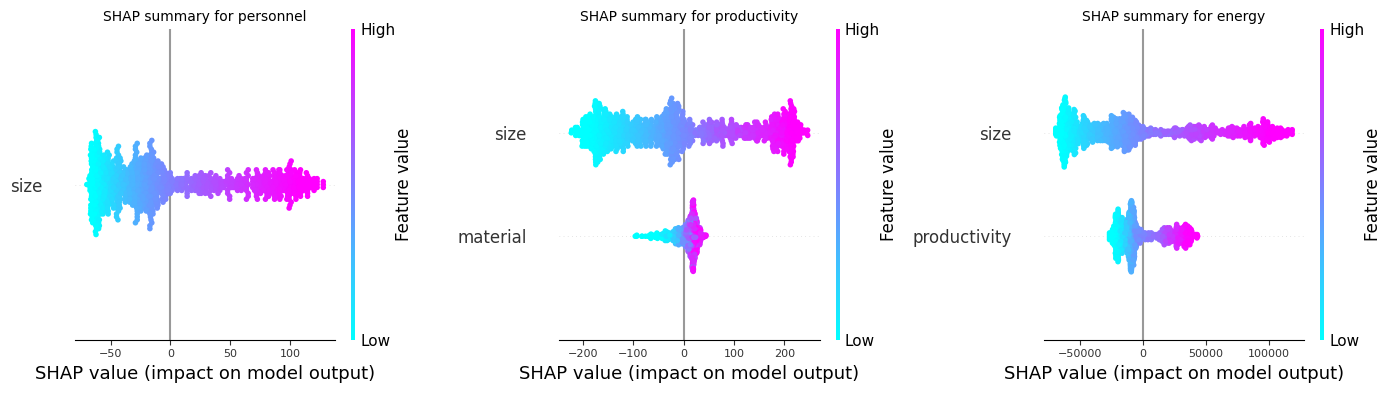

In [9]:

causal_models = trained_models["XGBoost"]["causal"]

# Nodes to plot
nodes = ['personnel', 'productivity', 'energy']

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, node in enumerate(nodes):
    model = causal_models[node]
    explainer = shap.TreeExplainer(model.model)
    
    # Get the parents (features) for this node
    parents = list(G.predecessors(node))
    X_node = train_df[parents].sample(1000)
    
    # Compute SHAP values
    shap_values = explainer.shap_values(X_node)
    
    # Create Explanation object for beeswarm
    explanation = shap.Explanation(values=shap_values, data=X_node.values, feature_names=X_node.columns)
    
    # Beeswarm plot in the subplot (fix: add plot_size=None)
    shap.plots.beeswarm(explanation, ax=axes[i], show=False, plot_size=None, color=plt.get_cmap('cool'))
    axes[i].set_title(f'SHAP summary for {node}', fontsize=10)
    axes[i].tick_params(axis='x', which='major', labelsize=8) 
    axes[i].tick_params(axis='y', which='major', labelsize=12) 


plt.tight_layout()
plt.savefig('visuals/causal_shap_summary_causal.svg', format='svg', bbox_inches='tight', dpi=1000)
plt.savefig('visuals/causal_shap_summary_causal.pdf', format='pdf', bbox_inches='tight', dpi=500)
plt.show()

# Partial Dependence plot for the causal GAM

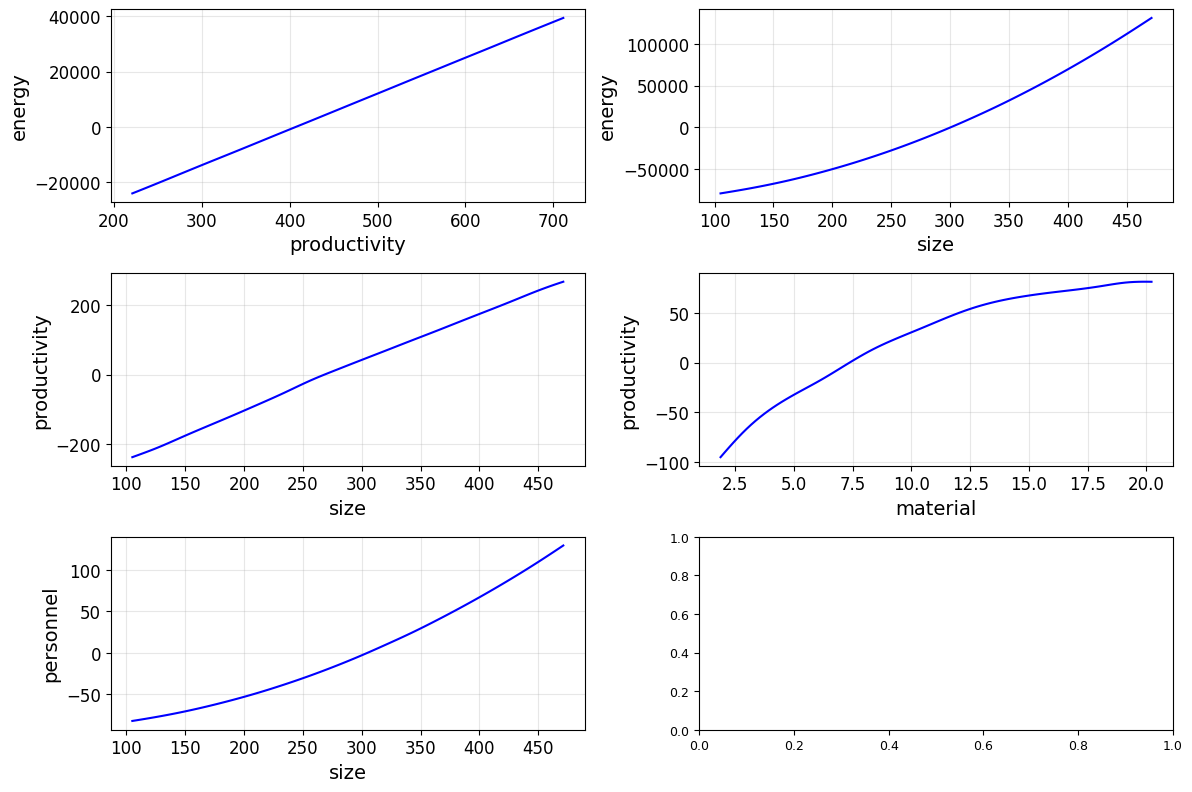

In [10]:


for name, model_dict in trained_models.items():
    if name != "GAM":
        continue  # Only plot for GAM
    
    causal_models = model_dict["causal"]
    
    # Nodes to plot
    nodes = [ 'energy', 'productivity', 'personnel']
    
    # Create a 3x2 grid for 6 subplots
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))
    axes = axes.flatten()  # Flatten to 1D array for easy indexing
    
    plot_idx = 0  # Index for the current subplot
    
    for node in nodes:
        gam_wrapper = causal_models[node]
        gam_model = gam_wrapper.model  # Access the underlying LinearGAM
        parents = list(G.predecessors(node))
        
        for feature in parents:
            try:
                # Generate grid for this term
                XX = gam_model.generate_X_grid(term=parents.index(feature))
                pdep = gam_model.partial_dependence(term=parents.index(feature), X=XX)
                
                ax = axes[plot_idx]
                ax.plot(XX[:, parents.index(feature)], pdep, color='blue')
                ax.set_xlabel(feature, fontsize=14)
                ax.set_ylabel(node, fontsize=14)
                ax.tick_params(axis='both', which='major', labelsize=12)
                ax.grid(True, alpha=0.3)
                
                # Format x-axis in scientific notation for 'energy'
                if feature == "energy":
                    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                
                plot_idx += 1
            except Exception as e:
                ax = axes[plot_idx]
                ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center', transform=ax.transAxes, fontsize=12)
                plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('visuals/causal_partial_dependence_plots.pdf', format='pdf', bbox_inches='tight', dpi=500)
    plt.show()

# ...existing code...

# Show symbolic equations

In [11]:
if symbolic_equations["causal"]:
    print("\n--- CAUSAL MODELS ---")
    for model_name, node_equations in symbolic_equations["causal"].items():
        print(f"\n{model_name}:")
        for node, equation in node_equations.items():
            print(f"  {node}: {equation}")

if symbolic_equations["traditional"]:
    print("\n--- TRADITIONAL MODELS ---")
    for model_name, equation in symbolic_equations["traditional"].items():
        print(f"\n{model_name}:")
        print(f"  Target equation: {equation}")



--- CAUSAL MODELS ---

SymbolicRegression:
  personnel: (size * (size * 0.0010)) + 14.9813
  energy: (productivity * 130.0056) - (-9998.7280 - (size * size))
  productivity: (((log1p(material) + 1.7779) / 3.1755) * size) + 63.5110

--- TRADITIONAL MODELS ---

SymbolicRegression:
  Target equation: ((personnel * 993.9957) + (productivity * 132.6140)) - 5526.7470


# Show causal graph

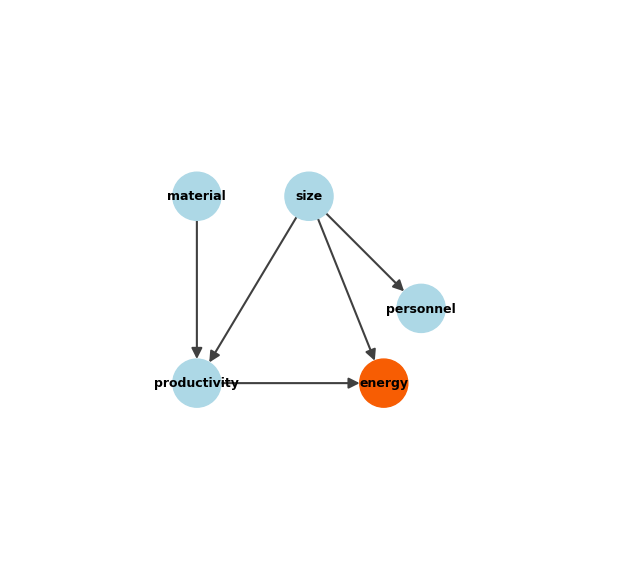

In [12]:

# ...existing code...
import matplotlib.pyplot as plt
import networkx as nx

def draw_custom_graph(ax, edges, positions, labels=None, y_threshold=0.7, node_size=1200):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Node colors: orange for 'energy', light blue otherwise
    node_colors = ["#F75D03" if node == 'energy' else 'lightblue' for node in G.nodes()]

    if labels is None:
        labels = {node: node for node in G.nodes()}

    nx.draw(
        G, pos=positions, ax=ax,
        with_labels=False,
        node_size=node_size,
        node_color=node_colors,
        edge_color='#404040',
        arrows=True,
        arrowsize=16,
        width=1.5
    )

    # Draw node names inside the nodes
    for node in G.nodes():
        x, y = positions[node]
        ax.text(x, y, node, ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')

    # Set tight limits based on node positions with a small padding
    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    pad_x = max(0.05, (max_x - min_x) * 0.12)
    pad_y = max(0.05, (max_y - min_y) * 0.12)
    ax.set_xlim(min_x - pad_x, max_x + pad_x)
    ax.set_ylim(min_y - pad_y, max_y + pad_y)

    ax.set_aspect('equal', 'box')
    ax.axis('off')


# ==========================================================
# Create one subplot with smaller canvas
fig, ax = plt.subplots(1, 1, figsize=(6, 6))  # smaller figure

# ---------- LEFT GRAPH ----------
edges_original = [
    ('size', 'productivity'),
    ('size', 'personnel'),
    ('size', 'energy'),
    ('material', 'productivity'),
    ('productivity', 'energy'),
]
positions_left = {
    'size': (0.93, 0.9),
    'productivity': (0.9, 0.85),
    'personnel': (0.96, 0.87),
    'energy': (0.95, 0.85),
    'material': (0.9, 0.9),
}

draw_custom_graph(ax, edges_original, positions_left, labels=None, node_size=1200)

plt.tight_layout(pad=0.08)
plt.savefig('visuals/static_SCM_example_no_formula.pdf', bbox_inches='tight', pad_inches=0.02, dpi=400, format='pdf')
plt.show()
